# MSc AI Fundamentals – Maze Pathfinding Using Logical Inference

## Problem Statement
Find a path from **(0,0)** to **(4,5)** in a **5 × 6** grid maze.  
Permitted moves: **Left, Right, Up, Down**.  
Obstacles (red nodes): `(0,1)  (2,1)  (2,3)  (3,1)  (3,4)  (4,4)`  
Boundaries act as walls.

## Approach & Criteria
| # | Criterion | Approach |
|---|-----------|----------|
| 1 | **Data structure representation** | Nodes as `(row, col)` tuples; obstacles in a `set`; adjacency via move vectors in a `dict`; parent map in a `dict` for path reconstruction |
| 2 | **Success criteria** | Goal is reached when the search frontier expands to node `(4, 5)` |
| 3 | **Blind search algorithms** | **BFS** (Breadth-First Search) and **DFS** (Depth-First Search) — both are uninformed algorithms |
| 4 | **Cost calculation** | Each move costs 1 unit; total cost = number of edges in the solution path |
| 5 | **Visualisation** | Matplotlib grid plots: maze layout, solution paths, BFS vs DFS comparison, and step-by-step state-space exploration |

## 1. Maze Representation Using Python Data Structures
The state space is represented **implicitly** using lightweight Python data structures — no explicit adjacency list is needed.

In [1]:
# ═══════════════════════════════════════════════════════════════════════
# 1. MAZE REPRESENTATION
# ═══════════════════════════════════════════════════════════════════════
#
# Data structures chosen:
#   • Nodes     → tuples (row, col)         — immutable, hashable, lightweight
#   • Grid size → two integers (ROWS, COLS) — define boundary walls
#   • Obstacles → set of tuples             — O(1) membership test
#   • Moves     → dict {name: (dr, dc)}     — maps direction labels to offsets
#   • Parent    → dict {node: parent_node}  — enables path reconstruction
#
# These structures together implicitly define the state space (graph)
# without needing to build an explicit adjacency list.

from collections import deque

# ── Grid dimensions ──────────────────────────────────────────────────
ROWS, COLS = 5, 6

# ── Start and goal nodes ─────────────────────────────────────────────
START = (0, 0)
GOAL  = (4, 5)

# ── Obstacles stored in a set for O(1) look-up ──────────────────────
OBSTACLES = {(0, 1), (2, 1), (2, 3), (3, 1), (3, 4), (4, 4)}

# ── Four permitted moves (direction name → row/col offset) ──────────
MOVES = {
    "UP":    (-1,  0),
    "DOWN":  ( 1,  0),
    "LEFT":  ( 0, -1),
    "RIGHT": ( 0,  1),
}

# ── Success criterion ────────────────────────────────────────────────
# The search succeeds when the algorithm discovers the GOAL node.

# ═══════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS  (used by both BFS and DFS)
# ═══════════════════════════════════════════════════════════════════════

def is_valid(pos):
    """Return True if `pos` is inside the grid and not an obstacle."""
    r, c = pos
    return 0 <= r < ROWS and 0 <= c < COLS and pos not in OBSTACLES

def reconstruct_path(parent, move_taken, goal):
    """Walk backwards from goal to start using parent pointers."""
    path, directions = [], []
    node = goal
    while node is not None:
        path.append(node)
        if move_taken[node] is not None:
            directions.append(move_taken[node])
        node = parent[node]
    path.reverse()
    directions.reverse()
    return path, directions

# ── Summary ──────────────────────────────────────────────────────────
print("Maze parameters loaded.")
print(f"  Grid size : {ROWS}×{COLS}  ({ROWS * COLS} nodes total)")
print(f"  Start     : {START}")
print(f"  Goal      : {GOAL}")
print(f"  Obstacles : {sorted(OBSTACLES)}")
print(f"  Free nodes: {ROWS * COLS - len(OBSTACLES)}")
print(f"\nData structures:")
print(f"  Nodes     → tuple   e.g. {START}")
print(f"  Obstacles → set     {type(OBSTACLES).__name__} (size {len(OBSTACLES)})")
print(f"  Moves     → dict    {list(MOVES.keys())}")
print(f"\nSuccess criterion: search terminates when GOAL {GOAL} is reached.")

Maze parameters loaded.
  Grid size : 5×6  (30 nodes total)
  Start     : (0, 0)
  Goal      : (4, 5)
  Obstacles : [(0, 1), (2, 1), (2, 3), (3, 1), (3, 4), (4, 4)]
  Free nodes: 24

Data structures:
  Nodes     → tuple   e.g. (0, 0)
  Obstacles → set     set (size 6)
  Moves     → dict    ['UP', 'DOWN', 'LEFT', 'RIGHT']

Success criterion: search terminates when GOAL (4, 5) is reached.


## 2. Breadth-First Search (BFS) — Blind Algorithm #1
BFS is a **blind (uninformed)** search algorithm that explores the state space **level by level** using a **FIFO queue**.  
It guarantees the **shortest path** in an unweighted graph because it examines all nodes at depth $d$ before any node at depth $d+1$.

In [2]:
# ═══════════════════════════════════════════════════════════════════════
# 2. BREADTH-FIRST SEARCH  (BFS)
# ═══════════════════════════════════════════════════════════════════════
#
# Properties of BFS:
#   • Complete  — guaranteed to find a solution if one exists
#   • Optimal   — finds the shortest path in an unweighted graph
#   • Time      — O(V + E)  where V = nodes, E = edges
#   • Space     — O(V)      (frontier queue + visited set)
#
# Logical-inference interpretation (forward chaining):
#   Knowledge Base (KB):
#       Fact 1 : reachable(START)
#   Inference Rule:
#       IF reachable(X) AND valid(Y) AND adjacent(X, Y)
#       THEN reachable(Y)
#   The rule is applied level-by-level until reachable(GOAL) is derived.

def bfs_search(start, goal):
    """
    Breadth-First Search implemented as forward-chaining logical inference.

    Returns
    -------
    found          : bool  — whether the goal is reachable
    parent         : dict  — maps each visited node to its predecessor
    move_taken     : dict  — maps each visited node to the direction used
    inference_log  : list  — step-by-step record of every inference
    nodes_explored : int   — total number of nodes expanded
    expanded_log   : list  — ordered list of nodes actually expanded (popped)
    """
    # --- Knowledge Base initialisation ---
    kb_reachable  = {start}          # set of known-reachable nodes (facts)
    parent        = {start: None}    # for path reconstruction
    move_taken    = {start: None}    # direction label per step
    inference_log = []               # record every inference step
    expanded_log  = []               # tracks nodes actually popped & expanded

    queue = deque([start])           # FIFO queue  ← key BFS data structure
    nodes_explored = 0

    while queue:
        current = queue.popleft()    # expand the OLDEST node first (BFS)
        nodes_explored += 1
        expanded_log.append(current) # record this node as truly expanded

        # ── Success criterion check (on expansion, consistent with DFS/A*) ──
        if current == goal:
            return True, parent, move_taken, inference_log, nodes_explored, expanded_log

        inferred_this_step = []

        for direction, (dr, dc) in MOVES.items():
            neighbor = (current[0] + dr, current[1] + dc)

            # Apply inference rule: valid AND not yet in KB?
            if is_valid(neighbor) and neighbor not in kb_reachable:
                kb_reachable.add(neighbor)           # derive new fact
                parent[neighbor]     = current
                move_taken[neighbor] = direction
                queue.append(neighbor)
                inferred_this_step.append((neighbor, direction))

        if inferred_this_step:
            inference_log.append((nodes_explored, current, inferred_this_step))

    return False, parent, move_taken, inference_log, nodes_explored, expanded_log

# ── Run BFS ──────────────────────────────────────────────────────────
bfs_found, bfs_parent, bfs_move_taken, bfs_log, bfs_nodes_explored, bfs_expanded = bfs_search(START, GOAL)

# Reconstruct the BFS solution path
bfs_path, bfs_directions = reconstruct_path(bfs_parent, bfs_move_taken, GOAL)
bfs_cost = len(bfs_path) - 1

print(f"Algorithm      : Breadth-First Search (blind / uninformed)")
print(f"Goal reachable : {bfs_found}")
print(f"Nodes explored : {bfs_nodes_explored}")
print(f"Path cost      : {bfs_cost} moves")
print(f"Path           : {' → '.join(str(p) for p in bfs_path)}")

Algorithm      : Breadth-First Search (blind / uninformed)
Goal reachable : True
Nodes explored : 24
Path cost      : 9 moves
Path           : (0, 0) → (1, 0) → (1, 1) → (1, 2) → (1, 3) → (1, 4) → (2, 4) → (2, 5) → (3, 5) → (4, 5)


In [3]:
# ── BFS Forward-Chaining Inference Log ────────────────────────────────
# Shows every rule application during BFS exploration.

print("=" * 60)
print("       BFS FORWARD-CHAINING INFERENCE LOG")
print("=" * 60)

for step_num, current_node, inferences in bfs_log:
    print(f"\nStep {step_num}: Expanding reachable({current_node})")
    for (neighbor, direction) in inferences:
        print(f"  Rule applied: reachable{current_node} ∧ adjacent{current_node, neighbor}"
              f" → reachable{neighbor}  [move: {direction}]")

print("\n" + "=" * 60)

       BFS FORWARD-CHAINING INFERENCE LOG

Step 1: Expanding reachable((0, 0))
  Rule applied: reachable(0, 0) ∧ adjacent((0, 0), (1, 0)) → reachable(1, 0)  [move: DOWN]

Step 2: Expanding reachable((1, 0))
  Rule applied: reachable(1, 0) ∧ adjacent((1, 0), (2, 0)) → reachable(2, 0)  [move: DOWN]
  Rule applied: reachable(1, 0) ∧ adjacent((1, 0), (1, 1)) → reachable(1, 1)  [move: RIGHT]

Step 3: Expanding reachable((2, 0))
  Rule applied: reachable(2, 0) ∧ adjacent((2, 0), (3, 0)) → reachable(3, 0)  [move: DOWN]

Step 4: Expanding reachable((1, 1))
  Rule applied: reachable(1, 1) ∧ adjacent((1, 1), (1, 2)) → reachable(1, 2)  [move: RIGHT]

Step 5: Expanding reachable((3, 0))
  Rule applied: reachable(3, 0) ∧ adjacent((3, 0), (4, 0)) → reachable(4, 0)  [move: DOWN]

Step 6: Expanding reachable((1, 2))
  Rule applied: reachable(1, 2) ∧ adjacent((1, 2), (0, 2)) → reachable(0, 2)  [move: UP]
  Rule applied: reachable(1, 2) ∧ adjacent((1, 2), (2, 2)) → reachable(2, 2)  [move: DOWN]
  Rule a

## 3. Depth-First Search (DFS) — Blind Algorithm #2
DFS is another **blind (uninformed)** search algorithm. Unlike BFS which uses a **FIFO queue**, DFS uses a **LIFO stack** — it dives as deep as possible along one branch before backtracking.  
DFS does **not** guarantee the shortest path.

In [4]:
# ═══════════════════════════════════════════════════════════════════════
# 3. DEPTH-FIRST SEARCH  (DFS)
# ═══════════════════════════════════════════════════════════════════════
#
# Properties of DFS:
#   • Complete  — yes (on finite graphs)
#   • Optimal   — NO — may find a longer path than necessary
#   • Time      — O(V + E)
#   • Space     — O(V)
#
# Logical-inference interpretation (forward chaining):
#   Knowledge Base (KB):
#       Fact 1 : reachable(START)
#   Inference Rule:
#       IF reachable(X) AND valid(Y) AND adjacent(X, Y)
#       THEN reachable(Y)
#   The rule is applied depth-first (LIFO) until reachable(GOAL) is derived.
#   Unlike BFS, the most recently derived fact is expanded first.

def dfs_search(start, goal):
    """
    Depth-First Search implemented as forward-chaining logical inference.

    Returns
    -------
    found          : bool  — whether the goal is reachable
    parent         : dict  — maps each visited node to its predecessor
    move_taken     : dict  — maps each visited node to the direction used
    inference_log  : list  — step-by-step record of every inference
    nodes_explored : int   — total number of nodes expanded
    expanded_log   : list  — ordered list of nodes actually expanded (popped)
    """
    # --- Knowledge Base initialisation ---
    kb_reachable  = {start}          # set of known-reachable nodes (facts)
    parent        = {start: None}    # for path reconstruction
    move_taken    = {start: None}    # direction label per step
    inference_log = []               # record every inference step
    expanded_log  = []               # tracks nodes actually popped & expanded

    stack = [start]               # LIFO stack ← key DFS data structure
    nodes_explored = 0

    while stack:
        current = stack.pop()     # expand the NEWEST node first (DFS)
        nodes_explored += 1
        expanded_log.append(current)  # record this node as truly expanded

        # ── Success criterion check ──
        if current == goal:
            return True, parent, move_taken, inference_log, nodes_explored, expanded_log

        inferred_this_step = []

        for direction, (dr, dc) in MOVES.items():
            neighbor = (current[0] + dr, current[1] + dc)

            # Apply inference rule: valid AND not yet in KB?
            if is_valid(neighbor) and neighbor not in kb_reachable:
                kb_reachable.add(neighbor)           # derive new fact
                parent[neighbor]     = current
                move_taken[neighbor] = direction
                stack.append(neighbor)
                inferred_this_step.append((neighbor, direction))

        if inferred_this_step:
            inference_log.append((nodes_explored, current, inferred_this_step))

    return False, parent, move_taken, inference_log, nodes_explored, expanded_log

# ── Run DFS ──────────────────────────────────────────────────────────
dfs_found, dfs_parent, dfs_move_taken, dfs_log, dfs_nodes_explored, dfs_expanded = dfs_search(START, GOAL)

# Reconstruct the DFS solution path
dfs_path, dfs_directions = reconstruct_path(dfs_parent, dfs_move_taken, GOAL)
dfs_cost = len(dfs_path) - 1

print(f"Algorithm      : Depth-First Search (blind / uninformed)")
print(f"Goal reachable : {dfs_found}")
print(f"Nodes explored : {dfs_nodes_explored}")
print(f"Path cost      : {dfs_cost} moves")
print(f"Path           : {' → '.join(str(p) for p in dfs_path)}")

Algorithm      : Depth-First Search (blind / uninformed)
Goal reachable : True
Nodes explored : 10
Path cost      : 9 moves
Path           : (0, 0) → (1, 0) → (1, 1) → (1, 2) → (1, 3) → (1, 4) → (1, 5) → (2, 5) → (3, 5) → (4, 5)


In [5]:
# ── DFS Forward-Chaining Inference Log ────────────────────────────────
# Shows every rule application during DFS exploration.

print("=" * 60)
print("       DFS FORWARD-CHAINING INFERENCE LOG")
print("=" * 60)

for step_num, current_node, inferences in dfs_log:
    print(f"\nStep {step_num}: Expanding reachable({current_node})")
    for (neighbor, direction) in inferences:
        print(f"  Rule applied: reachable{current_node} ∧ adjacent{current_node, neighbor}"
              f" → reachable{neighbor}  [move: {direction}]")

print("\n" + "=" * 60)

       DFS FORWARD-CHAINING INFERENCE LOG

Step 1: Expanding reachable((0, 0))
  Rule applied: reachable(0, 0) ∧ adjacent((0, 0), (1, 0)) → reachable(1, 0)  [move: DOWN]

Step 2: Expanding reachable((1, 0))
  Rule applied: reachable(1, 0) ∧ adjacent((1, 0), (2, 0)) → reachable(2, 0)  [move: DOWN]
  Rule applied: reachable(1, 0) ∧ adjacent((1, 0), (1, 1)) → reachable(1, 1)  [move: RIGHT]

Step 3: Expanding reachable((1, 1))
  Rule applied: reachable(1, 1) ∧ adjacent((1, 1), (1, 2)) → reachable(1, 2)  [move: RIGHT]

Step 4: Expanding reachable((1, 2))
  Rule applied: reachable(1, 2) ∧ adjacent((1, 2), (0, 2)) → reachable(0, 2)  [move: UP]
  Rule applied: reachable(1, 2) ∧ adjacent((1, 2), (2, 2)) → reachable(2, 2)  [move: DOWN]
  Rule applied: reachable(1, 2) ∧ adjacent((1, 2), (1, 3)) → reachable(1, 3)  [move: RIGHT]

Step 5: Expanding reachable((1, 3))
  Rule applied: reachable(1, 3) ∧ adjacent((1, 3), (0, 3)) → reachable(0, 3)  [move: UP]
  Rule applied: reachable(1, 3) ∧ adjacent((1,

## 4. BFS vs DFS — Results & Cost Comparison
Both algorithms have been run. This section prints both solution paths side-by-side, calculates their costs, and compares them.

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# 4. BFS vs DFS — RESULTS & COST COMPARISON
# ═══════════════════════════════════════════════════════════════════════

free_nodes = ROWS * COLS - len(OBSTACLES)

# ── Print BFS solution ───────────────────────────────────────────────
print("=" * 62)
print("  BFS SOLUTION  (Breadth-First Search)")
print("=" * 62)
for i, node in enumerate(bfs_path):
    tag  = "← START" if i == 0 else ("← GOAL" if i == len(bfs_path)-1 else "")
    move = f"(move: {bfs_directions[i-1]})" if i > 0 else ""
    print(f"  {i:>2}. {str(node):<10} {move:<20} {tag}")
print(f"\n  Path : {' → '.join(str(p) for p in bfs_path)}")
print(f"  Cost : {bfs_cost} moves")
print(f"  Nodes explored: {bfs_nodes_explored}")

# ── Print DFS solution ───────────────────────────────────────────────
print(f"\n{'=' * 62}")
print("  DFS SOLUTION  (Depth-First Search)")
print("=" * 62)
for i, node in enumerate(dfs_path):
    tag  = "← START" if i == 0 else ("← GOAL" if i == len(dfs_path)-1 else "")
    move = f"(move: {dfs_directions[i-1]})" if i > 0 else ""
    print(f"  {i:>2}. {str(node):<10} {move:<20} {tag}")
print(f"\n  Path : {' → '.join(str(p) for p in dfs_path)}")
print(f"  Cost : {dfs_cost} moves")
print(f"  Nodes explored: {dfs_nodes_explored}")

# ── Comparison table ─────────────────────────────────────────────────
print(f"\n{'=' * 62}")
print("  BFS vs DFS — COMPARISON TABLE")
print(f"{'=' * 62}")
print(f"  {'Metric':<30} {'BFS':>10} {'DFS':>10}")
print(f"  {'─' * 50}")
print(f"  {'Path cost (moves)':<30} {bfs_cost:>10} {dfs_cost:>10}")
print(f"  {'Nodes in path':<30} {len(bfs_path):>10} {len(dfs_path):>10}")
print(f"  {'Nodes explored':<30} {bfs_nodes_explored:>10} {dfs_nodes_explored:>10}")
print(f"  {'Search efficiency':<30} {bfs_nodes_explored/free_nodes:>9.1%} {dfs_nodes_explored/free_nodes:>9.1%}")
print(f"  {'Optimal (shortest path)?':<30} {'✓ Yes':>10} {'✗ No':>10}")
print(f"  {'Data structure':<30} {'Queue':>10} {'Stack':>10}")
print(f"  {'─' * 50}")

if bfs_cost < dfs_cost:
    print(f"\n  ➤ BFS found a SHORTER path ({bfs_cost} vs {dfs_cost} moves).")
    print(f"    BFS is optimal for unweighted graphs.")
elif bfs_cost == dfs_cost:
    print(f"\n  ➤ Both found equal-length paths ({bfs_cost} moves).")
    print(f"    But only BFS guarantees this; DFS was lucky.")
else:
    print(f"\n  ➤ DFS found a shorter path this time, but this is NOT guaranteed.")
print(f"  ➤ DFS explored {dfs_nodes_explored} nodes vs BFS {bfs_nodes_explored} nodes.")
print("=" * 62)

  BFS SOLUTION  (Breadth-First Search)
   0. (0, 0)                          ← START
   1. (1, 0)     (move: DOWN)         
   2. (1, 1)     (move: RIGHT)        
   3. (1, 2)     (move: RIGHT)        
   4. (1, 3)     (move: RIGHT)        
   5. (1, 4)     (move: RIGHT)        
   6. (2, 4)     (move: DOWN)         
   7. (2, 5)     (move: RIGHT)        
   8. (3, 5)     (move: DOWN)         
   9. (4, 5)     (move: DOWN)         ← GOAL

  Path : (0, 0) → (1, 0) → (1, 1) → (1, 2) → (1, 3) → (1, 4) → (2, 4) → (2, 5) → (3, 5) → (4, 5)
  Cost : 9 moves
  Nodes explored: 24

  DFS SOLUTION  (Depth-First Search)
   0. (0, 0)                          ← START
   1. (1, 0)     (move: DOWN)         
   2. (1, 1)     (move: RIGHT)        
   3. (1, 2)     (move: RIGHT)        
   4. (1, 3)     (move: RIGHT)        
   5. (1, 4)     (move: RIGHT)        
   6. (1, 5)     (move: RIGHT)        
   7. (2, 5)     (move: DOWN)         
   8. (3, 5)     (move: DOWN)         
   9. (4, 5)     (move: DO

## 5. Visualisation — BFS vs DFS Side-by-Side
The left panel shows the **BFS** solution and the right panel shows the **DFS** solution.  
- 🟥 Red = obstacle  |  🟩 Green = solution path  |  🟦 Blue = explored (not on path)  |  ⬜ Grey = unexplored

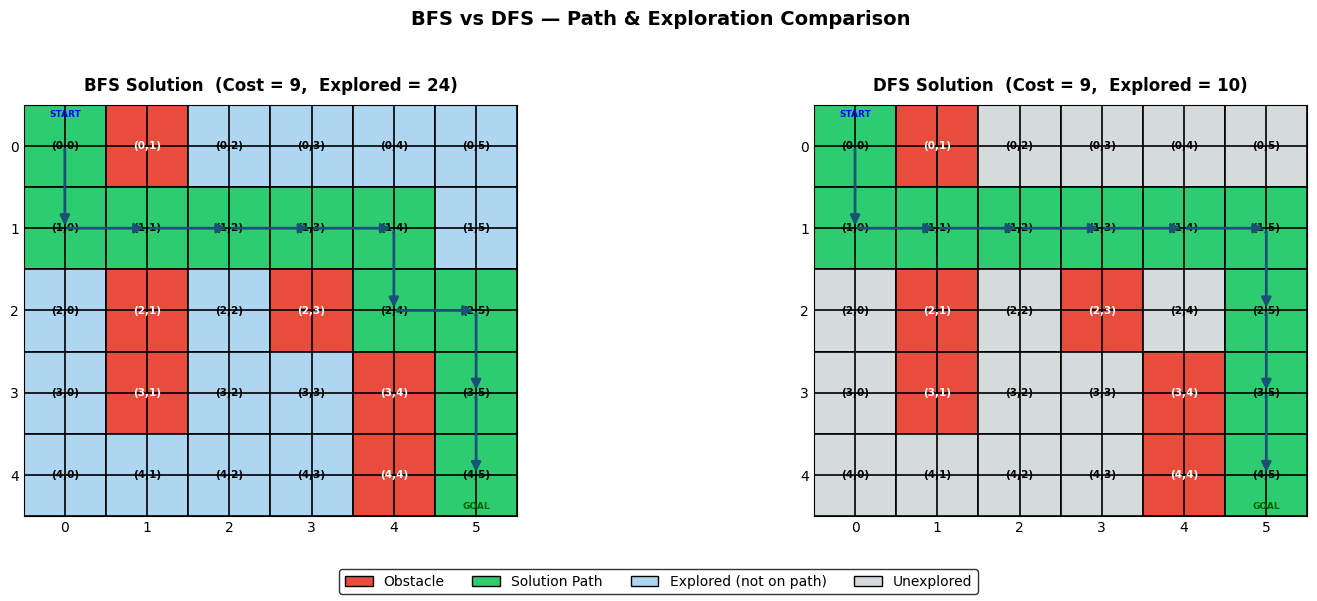

Figure saved as bfs_vs_dfs_comparison.png


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# 5. VISUALISATION — BFS vs DFS SIDE-BY-SIDE
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_maze(ax, title, path_cells=None, path_arrows=None, explored_cells=None):
    """Draw a single maze panel with obstacles, path, and explored regions."""
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.tick_params(length=0)
    ax.grid(True, linewidth=1.2, color="black")

    path_s = set(path_cells) if path_cells else set()
    expl_s = set(explored_cells) if explored_cells else set()

    for r in range(ROWS):
        for c in range(COLS):
            pos = (r, c)
            if pos in OBSTACLES:
                color = "#e74c3c"        # red — obstacle
            elif pos in path_s:
                color = "#2ecc71"        # green — solution path
            elif pos in expl_s:
                color = "#aed6f1"        # blue — explored
            else:
                color = "#d5dbdb"        # grey — unexplored
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                 facecolor=color, edgecolor="black", lw=1.2)
            ax.add_patch(rect)
            fontc = "white" if pos in OBSTACLES else "black"
            ax.text(c, r, f"({r},{c})", ha="center", va="center",
                    fontsize=7.5, fontweight="bold", color=fontc)

    # Mark start & goal
    ax.text(START[1], START[0] - 0.38, "START", ha="center", va="center",
            fontsize=6.5, color="blue", fontweight="bold")
    ax.text(GOAL[1], GOAL[0] + 0.38, "GOAL", ha="center", va="center",
            fontsize=6.5, color="darkgreen", fontweight="bold")

    # Draw path arrows
    if path_arrows:
        for (r1, c1), (r2, c2) in path_arrows:
            ax.annotate("", xy=(c2, r2), xytext=(c1, r1),
                        arrowprops=dict(arrowstyle="-|>", color="#1a5276",
                                        lw=2, mutation_scale=14))

# ── Compute explored sets (nodes actually expanded, NOT on the path) ──
# IMPORTANT: use bfs_expanded / dfs_expanded (nodes popped from queue/stack)
# NOT parent.keys() which includes all *discovered* neighbours.
bfs_path_set     = set(bfs_path)
bfs_explored_set = set(bfs_expanded) - bfs_path_set - OBSTACLES
bfs_edges        = list(zip(bfs_path[:-1], bfs_path[1:]))

dfs_path_set     = set(dfs_path)
dfs_explored_set = set(dfs_expanded) - dfs_path_set - OBSTACLES
dfs_edges        = list(zip(dfs_path[:-1], dfs_path[1:]))

# ── Create figure with 2 panels ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

draw_maze(ax1,
          f"BFS Solution  (Cost = {bfs_cost},  Explored = {bfs_nodes_explored})",
          bfs_path, bfs_edges, bfs_explored_set)

draw_maze(ax2,
          f"DFS Solution  (Cost = {dfs_cost},  Explored = {dfs_nodes_explored})",
          dfs_path, dfs_edges, dfs_explored_set)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#e74c3c", edgecolor="black", label="Obstacle"),
    mpatches.Patch(facecolor="#2ecc71", edgecolor="black", label="Solution Path"),
    mpatches.Patch(facecolor="#aed6f1", edgecolor="black", label="Explored (not on path)"),
    mpatches.Patch(facecolor="#d5dbdb", edgecolor="black", label="Unexplored"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           fontsize=10, frameon=True, edgecolor="black")

plt.suptitle("BFS vs DFS — Path & Exploration Comparison", fontsize=14,
             fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("bfs_vs_dfs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as bfs_vs_dfs_comparison.png")

## 6. Visualisation — BFS State-Space Exploration Over Time
This shows how BFS explores the state space **incrementally**, expanding outward level by level.  
The final panel highlights the solution path in green.

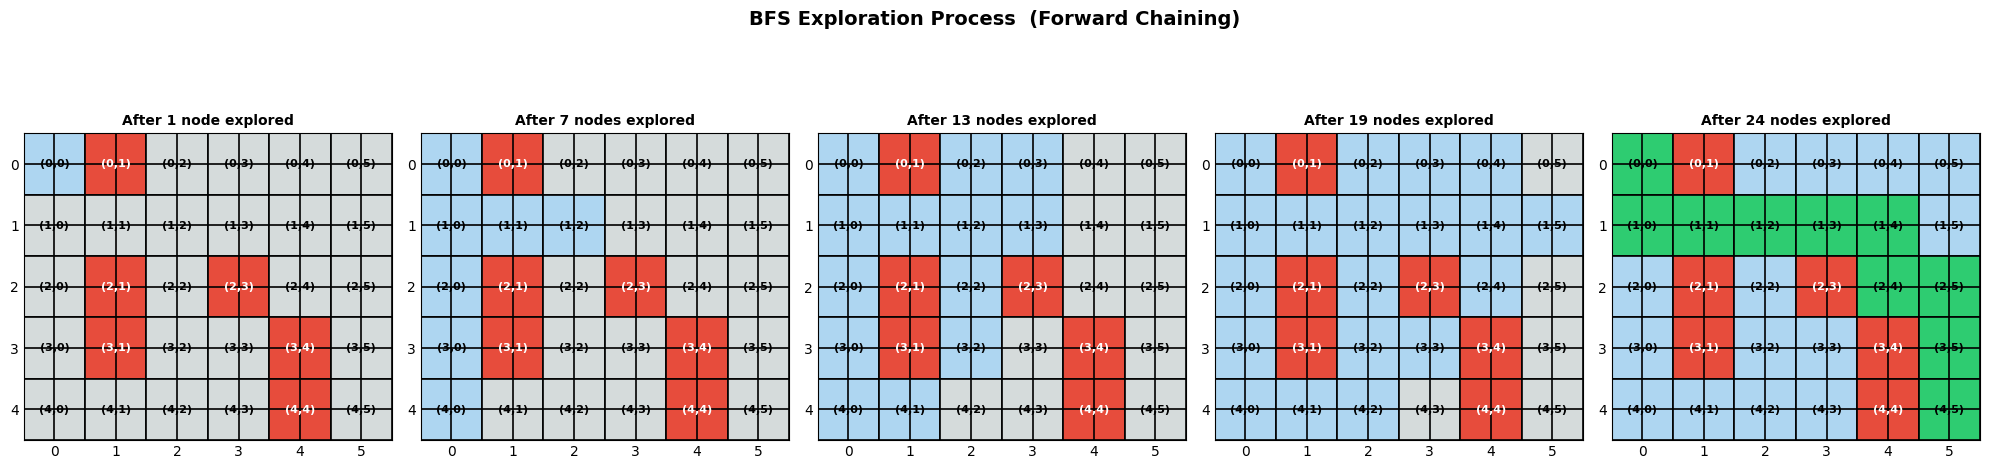

Figure saved as bfs_exploration_steps.png


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# 6. BFS STATE-SPACE EXPLORATION OVER TIME
# ═══════════════════════════════════════════════════════════════════════
# Snapshots at 5 stages show how BFS expands outward from the start.

# Build cumulative explored order from the BFS inference log
explored_order = [START]
for _, current_node, inferences in bfs_log:
    if current_node not in explored_order:
        explored_order.append(current_node)
    for (nb, _) in inferences:
        if nb not in explored_order:
            explored_order.append(nb)

# Pick 5 evenly-spaced snapshots
n = len(explored_order)
snapshots = sorted(set([0, n // 4, n // 2, 3 * n // 4, n - 1]))

fig_exp, axes_exp = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 5))
if len(snapshots) == 1:
    axes_exp = [axes_exp]

for idx, s in enumerate(snapshots):
    explored_so_far = set(explored_order[:s + 1])
    is_final = (s == n - 1)

    ax = axes_exp[idx]
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.tick_params(length=0)
    ax.grid(True, linewidth=1.2, color="black")

    path_s = set(bfs_path) if is_final else set()
    for r in range(ROWS):
        for c in range(COLS):
            pos = (r, c)
            if pos in OBSTACLES:
                color = "#e74c3c"
            elif pos in path_s:
                color = "#2ecc71"
            elif pos in explored_so_far:
                color = "#aed6f1"
            else:
                color = "#d5dbdb"
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                 facecolor=color, edgecolor="black", lw=1.2)
            ax.add_patch(rect)
            fontc = "white" if pos in OBSTACLES else "black"
            ax.text(c, r, f"({r},{c})", ha="center", va="center",
                    fontsize=8, fontweight="bold", color=fontc)

    ax.set_title(f"After {s + 1} node{'s' if s > 0 else ''} explored",
                 fontsize=10, fontweight="bold")

plt.suptitle("BFS Exploration Process  (Forward Chaining)", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("bfs_exploration_steps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as bfs_exploration_steps.png")

## 6b. Visualisation — DFS State-Space Exploration Over Time
This shows how DFS explores the state space **incrementally**, diving deep along one branch before backtracking.  
The final panel highlights the solution path in green.

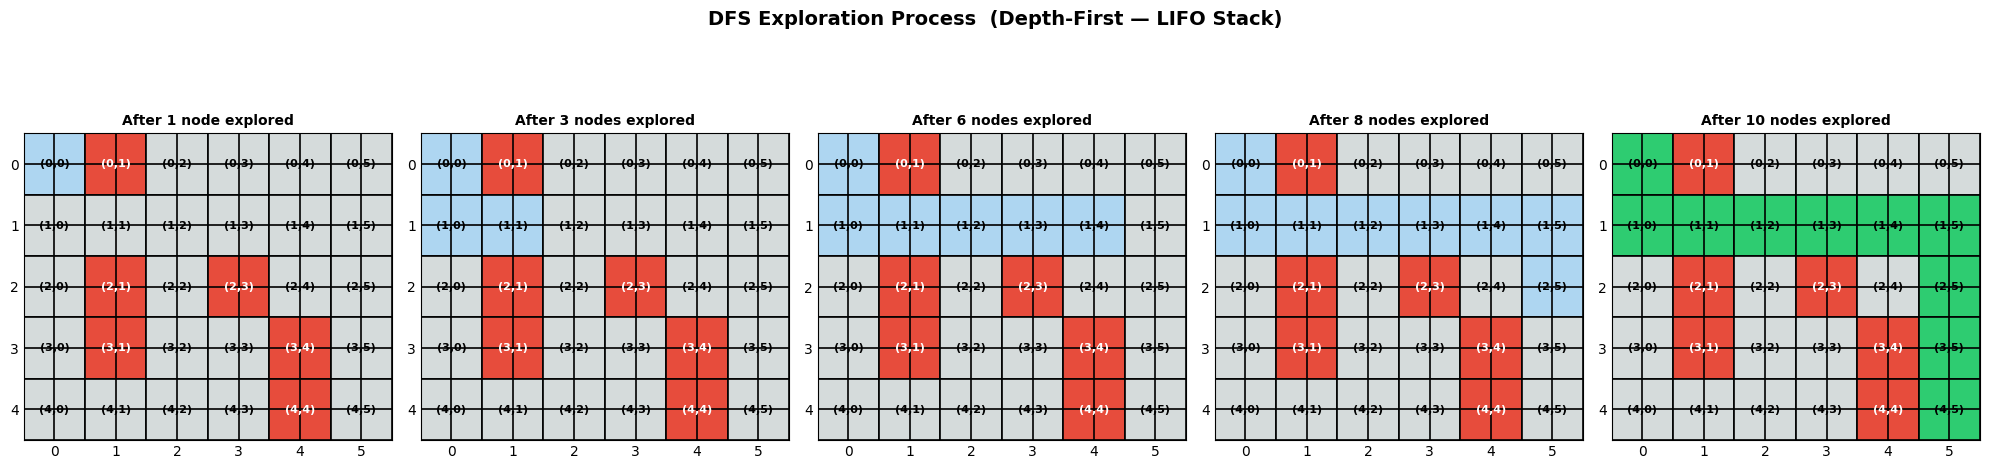

Figure saved as dfs_exploration_steps.png


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# 6b. DFS STATE-SPACE EXPLORATION OVER TIME
# ═══════════════════════════════════════════════════════════════════════
# Snapshots at 5 stages show how DFS dives deep before backtracking.

# Build cumulative explored order from the DFS expanded log
dfs_explored_order = list(dfs_expanded)  # nodes in the order they were popped

# Pick 5 evenly-spaced snapshots
n_dfs = len(dfs_explored_order)
dfs_snapshots = sorted(set([0, n_dfs // 4, n_dfs // 2, 3 * n_dfs // 4, n_dfs - 1]))

fig_dfs_exp, axes_dfs_exp = plt.subplots(1, len(dfs_snapshots), figsize=(4 * len(dfs_snapshots), 5))
if len(dfs_snapshots) == 1:
    axes_dfs_exp = [axes_dfs_exp]

for idx, s in enumerate(dfs_snapshots):
    explored_so_far = set(dfs_explored_order[:s + 1])
    is_final = (s == n_dfs - 1)

    ax = axes_dfs_exp[idx]
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.tick_params(length=0)
    ax.grid(True, linewidth=1.2, color="black")

    path_s = set(dfs_path) if is_final else set()
    for r in range(ROWS):
        for c in range(COLS):
            pos = (r, c)
            if pos in OBSTACLES:
                color = "#e74c3c"
            elif pos in path_s:
                color = "#2ecc71"
            elif pos in explored_so_far:
                color = "#aed6f1"
            else:
                color = "#d5dbdb"
            rect = plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                 facecolor=color, edgecolor="black", lw=1.2)
            ax.add_patch(rect)
            fontc = "white" if pos in OBSTACLES else "black"
            ax.text(c, r, f"({r},{c})", ha="center", va="center",
                    fontsize=8, fontweight="bold", color=fontc)

    ax.set_title(f"After {s + 1} node{'s' if s > 0 else ''} explored",
                 fontsize=10, fontweight="bold")

plt.suptitle("DFS Exploration Process  (Depth-First — LIFO Stack)", fontsize=14,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("dfs_exploration_steps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as dfs_exploration_steps.png")

## 7. A* Search — Informed (Heuristic) Algorithm
A* is an **informed (heuristic)** search algorithm that combines:
- **g(n)** — the actual cost from the start to the current node (like Dijkstra)
- **h(n)** — a heuristic estimate of the cost from the current node to the goal

The evaluation function is **f(n) = g(n) + h(n)**.

**Heuristic chosen:** Manhattan Distance — `|row₁ − row₂| + |col₁ − col₂|`  
This heuristic is **admissible** (never overestimates) and **consistent** for grid movement with 4 directions, so A* is guaranteed to find the **optimal (shortest) path**.

| Property | Value |
|----------|-------|
| Complete | ✓ Yes |
| Optimal | ✓ Yes (with admissible heuristic) |
| Data structure | Priority Queue (min-heap) |
| Time complexity | O(V log V) |
| Space complexity | O(V) |

In [10]:
# ═══════════════════════════════════════════════════════════════════════
# 7. A* SEARCH  (Informed / Heuristic)
# ═══════════════════════════════════════════════════════════════════════
#
# A* combines the strengths of Dijkstra (exact cost so far) with a
# heuristic estimate (cost to go).  It uses a PRIORITY QUEUE (min-heap)
# ordered by f(n) = g(n) + h(n).
#
# Heuristic: Manhattan Distance — admissible & consistent for 4-dir grids.
#   h(n) = |row_n - row_goal| + |col_n - col_goal|
#
# Because every edge costs 1 and the heuristic is admissible,
# A* is guaranteed to return the optimal (shortest) path — just like BFS,
# but typically exploring FEWER nodes.

import heapq   # min-heap for the priority queue

def manhattan(node, goal):
    """Admissible heuristic: Manhattan distance to the goal."""
    return abs(node[0] - goal[0]) + abs(node[1] - goal[1])

def astar_search(start, goal):
    """
    A* Search using Manhattan distance heuristic.

    Returns
    -------
    found           : bool
    parent          : dict  — maps each visited node to its predecessor
    move_taken      : dict  — direction used to reach each node
    exploration_log : list  — ordered list of nodes as they were expanded
    nodes_explored  : int   — total nodes expanded
    g_costs         : dict  — actual cost from start to each visited node
    """
    # g(n) = cost from start to n;  f(n) = g(n) + h(n)
    g_cost     = {start: 0}
    parent     = {start: None}
    move_taken = {start: None}
    exploration_log = []

    # Priority queue entries: (f_cost, tie_breaker, node)
    # The tie_breaker (counter) ensures FIFO order for equal f-values.
    counter = 0
    open_set = [(manhattan(start, goal), counter, start)]
    closed_set = set()

    nodes_explored = 0

    while open_set:
        f, _, current = heapq.heappop(open_set)

        # Skip if already expanded (closed)
        if current in closed_set:
            continue

        closed_set.add(current)
        nodes_explored += 1
        exploration_log.append(current)

        # ── Success criterion check ──
        if current == goal:
            return True, parent, move_taken, exploration_log, nodes_explored, g_cost

        for direction, (dr, dc) in MOVES.items():
            neighbor = (current[0] + dr, current[1] + dc)

            if not is_valid(neighbor) or neighbor in closed_set:
                continue

            tentative_g = g_cost[current] + 1   # each move costs 1

            # Only update if this path is better
            if tentative_g < g_cost.get(neighbor, float('inf')):
                g_cost[neighbor]     = tentative_g
                parent[neighbor]     = current
                move_taken[neighbor] = direction
                f_cost = tentative_g + manhattan(neighbor, goal)
                counter += 1
                heapq.heappush(open_set, (f_cost, counter, neighbor))

    return False, parent, move_taken, exploration_log, nodes_explored, g_cost

# ── Run A* ───────────────────────────────────────────────────────────
astar_found, astar_parent, astar_move_taken, astar_log, astar_nodes_explored, astar_g = \
    astar_search(START, GOAL)

# Reconstruct the A* solution path
astar_path, astar_directions = reconstruct_path(astar_parent, astar_move_taken, GOAL)
astar_cost = len(astar_path) - 1

print(f"Algorithm      : A* Search (informed / heuristic)")
print(f"Heuristic      : Manhattan Distance")
print(f"Goal reachable : {astar_found}")
print(f"Nodes explored : {astar_nodes_explored}")
print(f"Path cost      : {astar_cost} moves")
print(f"Path           : {' → '.join(str(p) for p in astar_path)}")

# Show heuristic values along the solution path
print(f"\nHeuristic values along the A* path:")
print(f"  {'Node':<10} {'g(n)':<6} {'h(n)':<6} {'f(n)':<6}")
print(f"  {'─' * 28}")
for node in astar_path:
    g = astar_g[node]
    h = manhattan(node, GOAL)
    f = g + h
    print(f"  {str(node):<10} {g:<6} {h:<6} {f:<6}")

Algorithm      : A* Search (informed / heuristic)
Heuristic      : Manhattan Distance
Goal reachable : True
Nodes explored : 20
Path cost      : 9 moves
Path           : (0, 0) → (1, 0) → (1, 1) → (1, 2) → (1, 3) → (1, 4) → (2, 4) → (2, 5) → (3, 5) → (4, 5)

Heuristic values along the A* path:
  Node       g(n)   h(n)   f(n)  
  ────────────────────────────
  (0, 0)     0      9      9     
  (1, 0)     1      8      9     
  (1, 1)     2      7      9     
  (1, 2)     3      6      9     
  (1, 3)     4      5      9     
  (1, 4)     5      4      9     
  (2, 4)     6      3      9     
  (2, 5)     7      2      9     
  (3, 5)     8      1      9     
  (4, 5)     9      0      9     


## 8. BFS vs DFS vs A* — Full Comparison
All three algorithms have been run on the same maze. This section compares their solution paths, costs, exploration counts, and algorithmic properties side-by-side.

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# 8. BFS vs DFS vs A* — FULL COMPARISON
# ═══════════════════════════════════════════════════════════════════════

free_nodes = ROWS * COLS - len(OBSTACLES)

# ── Print A* solution step-by-step ───────────────────────────────────
print("=" * 62)
print("  A* SOLUTION  (A-Star Search — Manhattan Heuristic)")
print("=" * 62)
for i, node in enumerate(astar_path):
    tag  = "← START" if i == 0 else ("← GOAL" if i == len(astar_path)-1 else "")
    move = f"(move: {astar_directions[i-1]})" if i > 0 else ""
    print(f"  {i:>2}. {str(node):<10} {move:<20} {tag}")
print(f"\n  Path : {' → '.join(str(p) for p in astar_path)}")
print(f"  Cost : {astar_cost} moves")
print(f"  Nodes explored: {astar_nodes_explored}")

# ── Three-way comparison table ───────────────────────────────────────
print(f"\n{'=' * 72}")
print("  BFS vs DFS vs A* — COMPARISON TABLE")
print(f"{'=' * 72}")
print(f"  {'Metric':<35} {'BFS':>10} {'DFS':>10} {'A*':>10}")
print(f"  {'─' * 65}")
print(f"  {'Algorithm type':<35} {'Blind':>10} {'Blind':>10} {'Informed':>10}")
print(f"  {'Path cost (moves)':<35} {bfs_cost:>10} {dfs_cost:>10} {astar_cost:>10}")
print(f"  {'Nodes in path':<35} {len(bfs_path):>10} {len(dfs_path):>10} {len(astar_path):>10}")
print(f"  {'Nodes explored':<35} {bfs_nodes_explored:>10} {dfs_nodes_explored:>10} {astar_nodes_explored:>10}")
print(f"  {'Search efficiency':<35} {bfs_nodes_explored/free_nodes:>9.1%} {dfs_nodes_explored/free_nodes:>9.1%} {astar_nodes_explored/free_nodes:>9.1%}")
print(f"  {'Optimal (shortest path)?':<35} {'✓ Yes':>10} {'✗ No':>10} {'✓ Yes':>10}")
print(f"  {'Uses heuristic?':<35} {'✗ No':>10} {'✗ No':>10} {'✓ Yes':>10}")
print(f"  {'Data structure':<35} {'Queue':>10} {'Stack':>10} {'Heap':>10}")
print(f"  {'─' * 65}")

# ── Analysis ─────────────────────────────────────────────────────────
best_explored = min(bfs_nodes_explored, dfs_nodes_explored, astar_nodes_explored)
print(f"\n  Key observations:")
print(f"  ➤ BFS explored {bfs_nodes_explored} nodes — guarantees shortest path (blind).")
print(f"  ➤ DFS explored {dfs_nodes_explored} nodes — no optimality guarantee.")
print(f"  ➤ A*  explored {astar_nodes_explored} nodes — guarantees shortest path (informed).")
if astar_nodes_explored <= bfs_nodes_explored:
    print(f"  ➤ A* explored ≤ BFS nodes while still guaranteeing optimality.")
    print(f"    The Manhattan heuristic guided the search toward the goal.")
print(f"{'=' * 72}")

  A* SOLUTION  (A-Star Search — Manhattan Heuristic)
   0. (0, 0)                          ← START
   1. (1, 0)     (move: DOWN)         
   2. (1, 1)     (move: RIGHT)        
   3. (1, 2)     (move: RIGHT)        
   4. (1, 3)     (move: RIGHT)        
   5. (1, 4)     (move: RIGHT)        
   6. (2, 4)     (move: DOWN)         
   7. (2, 5)     (move: RIGHT)        
   8. (3, 5)     (move: DOWN)         
   9. (4, 5)     (move: DOWN)         ← GOAL

  Path : (0, 0) → (1, 0) → (1, 1) → (1, 2) → (1, 3) → (1, 4) → (2, 4) → (2, 5) → (3, 5) → (4, 5)
  Cost : 9 moves
  Nodes explored: 20

  BFS vs DFS vs A* — COMPARISON TABLE
  Metric                                     BFS        DFS         A*
  ─────────────────────────────────────────────────────────────────
  Algorithm type                           Blind      Blind   Informed
  Path cost (moves)                            9          9          9
  Nodes in path                               10         10         10
  Nodes explored 

## 9. Visualisation — BFS vs DFS vs A* (All Three)
Three panels showing each algorithm's solution path and explored nodes.  
A* typically explores fewer nodes than BFS while still finding the optimal path, thanks to the Manhattan distance heuristic guiding the search toward the goal.

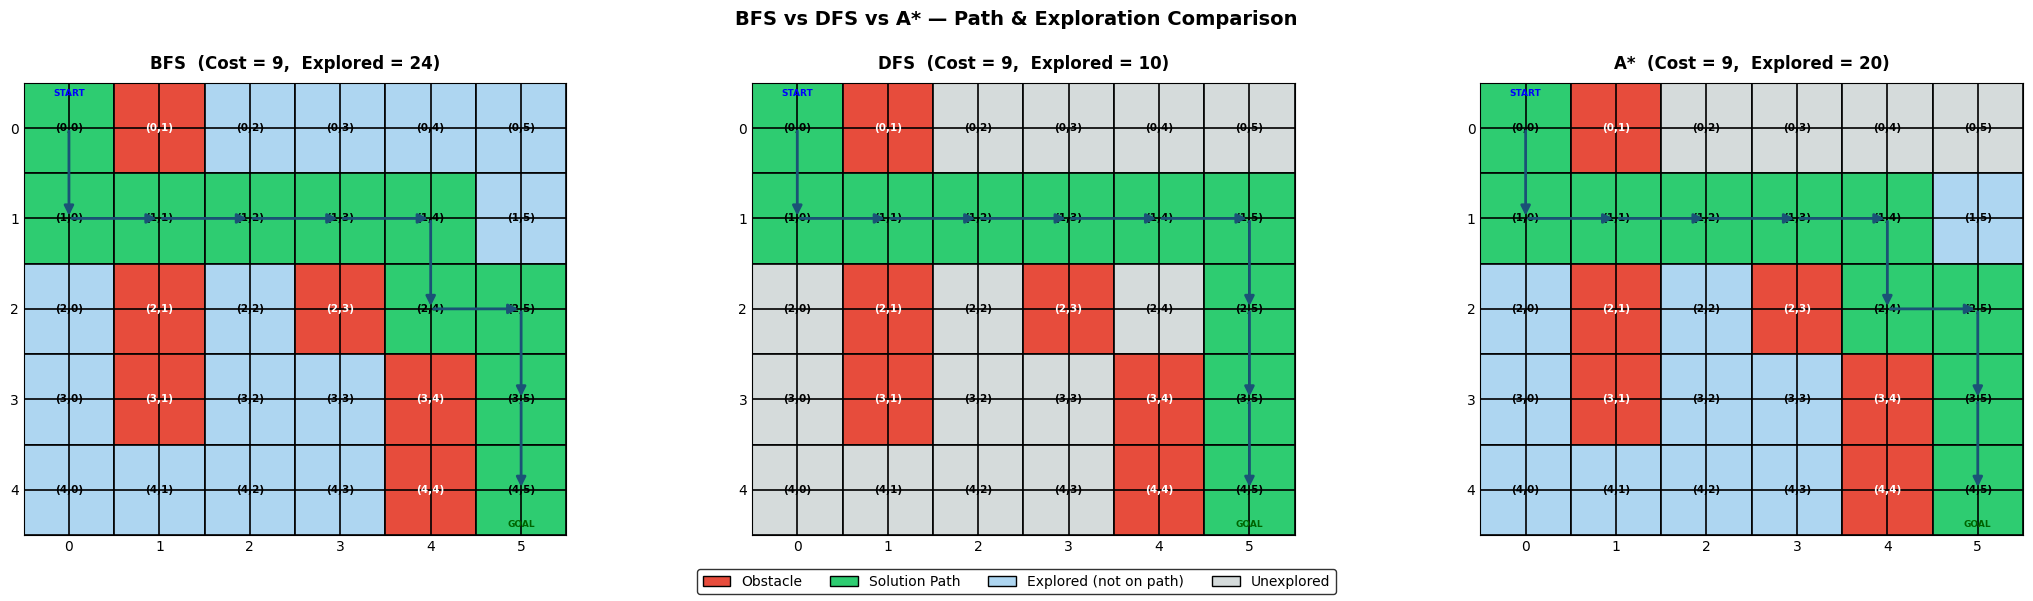

Figure saved as bfs_dfs_astar_comparison.png


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# 9. VISUALISATION — BFS vs DFS vs A*  (THREE PANELS)
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Compute A* explored set ──────────────────────────────────────────
# IMPORTANT: use astar_log (nodes actually expanded / popped from heap)
# NOT astar_parent.keys() which includes all *discovered* nodes
# (neighbours pushed to the open set but never expanded).
astar_path_set     = set(astar_path)
astar_explored_set = set(astar_log) - astar_path_set - OBSTACLES
astar_edges        = list(zip(astar_path[:-1], astar_path[1:]))

# ── Create figure with 3 panels ─────────────────────────────────────
fig_all, (ax_bfs, ax_dfs, ax_astar) = plt.subplots(1, 3, figsize=(22, 6))

draw_maze(ax_bfs,
          f"BFS  (Cost = {bfs_cost},  Explored = {bfs_nodes_explored})",
          bfs_path, bfs_edges, bfs_explored_set)

draw_maze(ax_dfs,
          f"DFS  (Cost = {dfs_cost},  Explored = {dfs_nodes_explored})",
          dfs_path, dfs_edges, dfs_explored_set)

draw_maze(ax_astar,
          f"A*  (Cost = {astar_cost},  Explored = {astar_nodes_explored})",
          astar_path, astar_edges, astar_explored_set)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#e74c3c", edgecolor="black", label="Obstacle"),
    mpatches.Patch(facecolor="#2ecc71", edgecolor="black", label="Solution Path"),
    mpatches.Patch(facecolor="#aed6f1", edgecolor="black", label="Explored (not on path)"),
    mpatches.Patch(facecolor="#d5dbdb", edgecolor="black", label="Unexplored"),
]
fig_all.legend(handles=legend_elements, loc="lower center", ncol=4,
               fontsize=10, frameon=True, edgecolor="black")

plt.suptitle("BFS vs DFS vs A* — Path & Exploration Comparison", fontsize=14,
             fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("bfs_dfs_astar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as bfs_dfs_astar_comparison.png")

## 10. Dijkstra's Algorithm — Uninformed (Optimal) Algorithm
Dijkstra's algorithm is an **uninformed (blind)** search algorithm that finds the **shortest path** from a source node to all other nodes in a weighted graph. It uses a **priority queue (min-heap)** ordered by the cumulative cost **g(n)** from the start.

Unlike A*, Dijkstra does **not** use a heuristic — it relies solely on the actual cost accumulated so far. In an unweighted grid (where every edge costs 1), Dijkstra behaves similarly to BFS but uses a heap instead of a FIFO queue.

**Key difference from A*:** Dijkstra uses **f(n) = g(n)** only, whereas A* uses **f(n) = g(n) + h(n)**.

| Property | Value |
|----------|-------|
| Complete | ✓ Yes |
| Optimal | ✓ Yes (guaranteed shortest path) |
| Data structure | Priority Queue (min-heap) |
| Uses heuristic | ✗ No (blind / uninformed) |
| Time complexity | O(V log V) |
| Space complexity | O(V) |

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# 10. DIJKSTRA'S ALGORITHM  (Uninformed / Blind — Optimal)
# ═══════════════════════════════════════════════════════════════════════
#
# Dijkstra's algorithm finds the shortest path from the start to all
# reachable nodes using a PRIORITY QUEUE (min-heap) ordered by the
# cumulative cost g(n).
#
# Unlike A*, Dijkstra does NOT use a heuristic — it expands the node
# with the smallest g(n) first, guaranteeing optimality.
#
# In an unweighted grid (each edge costs 1), Dijkstra behaves like BFS
# but uses a heap instead of a FIFO queue.

import heapq   # min-heap for the priority queue

def dijkstra_search(start, goal):
    """
    Dijkstra's Algorithm — shortest path without heuristic.

    Returns
    -------
    found           : bool
    parent          : dict  — maps each visited node to its predecessor
    move_taken      : dict  — direction used to reach each node
    exploration_log : list  — ordered list of nodes as they were expanded
    nodes_explored  : int   — total nodes expanded
    g_costs         : dict  — actual cost from start to each visited node
    """
    # g(n) = cost from start to n
    g_cost     = {start: 0}
    parent     = {start: None}
    move_taken = {start: None}
    exploration_log = []

    # Priority queue entries: (g_cost, tie_breaker, node)
    # The tie_breaker (counter) ensures FIFO order for equal g-values.
    counter = 0
    open_set = [(0, counter, start)]
    closed_set = set()

    nodes_explored = 0

    while open_set:
        g, _, current = heapq.heappop(open_set)

        # Skip if already expanded (closed)
        if current in closed_set:
            continue

        closed_set.add(current)
        nodes_explored += 1
        exploration_log.append(current)

        # ── Success criterion check ──
        if current == goal:
            return True, parent, move_taken, exploration_log, nodes_explored, g_cost

        for direction, (dr, dc) in MOVES.items():
            neighbor = (current[0] + dr, current[1] + dc)

            if not is_valid(neighbor) or neighbor in closed_set:
                continue

            tentative_g = g_cost[current] + 1   # each move costs 1

            # Only update if this path is better
            if tentative_g < g_cost.get(neighbor, float('inf')):
                g_cost[neighbor]     = tentative_g
                parent[neighbor]     = current
                move_taken[neighbor] = direction
                counter += 1
                heapq.heappush(open_set, (tentative_g, counter, neighbor))

    return False, parent, move_taken, exploration_log, nodes_explored, g_cost

# ── Run Dijkstra ─────────────────────────────────────────────────────
dij_found, dij_parent, dij_move_taken, dij_log, dij_nodes_explored, dij_g = \
    dijkstra_search(START, GOAL)

# Reconstruct the Dijkstra solution path
dij_path, dij_directions = reconstruct_path(dij_parent, dij_move_taken, GOAL)
dij_cost = len(dij_path) - 1

print(f"Algorithm      : Dijkstra's Algorithm (blind / uninformed)")
print(f"Goal reachable : {dij_found}")
print(f"Nodes explored : {dij_nodes_explored}")
print(f"Path cost      : {dij_cost} moves")
print(f"Path           : {' → '.join(str(p) for p in dij_path)}")

# Show g-cost values along the solution path
print(f"\nCost values along Dijkstra's path:")
print(f"  {'Node':<10} {'g(n)':<6}")
print(f"  {'─' * 16}")
for node in dij_path:
    g = dij_g[node]
    print(f"  {str(node):<10} {g:<6}")

Algorithm      : Dijkstra's Algorithm (blind / uninformed)
Goal reachable : True
Nodes explored : 24
Path cost      : 9 moves
Path           : (0, 0) → (1, 0) → (1, 1) → (1, 2) → (1, 3) → (1, 4) → (2, 4) → (2, 5) → (3, 5) → (4, 5)

Cost values along Dijkstra's path:
  Node       g(n)  
  ────────────────
  (0, 0)     0     
  (1, 0)     1     
  (1, 1)     2     
  (1, 2)     3     
  (1, 3)     4     
  (1, 4)     5     
  (2, 4)     6     
  (2, 5)     7     
  (3, 5)     8     
  (4, 5)     9     


## 11. BFS vs DFS vs A* vs Dijkstra — Full Comparison
All four algorithms have been run on the same maze. This section compares their solution paths, costs, exploration counts, and algorithmic properties side-by-side.

In [14]:
# ═══════════════════════════════════════════════════════════════════════
# 11. BFS vs DFS vs A* vs DIJKSTRA — FULL COMPARISON
# ═══════════════════════════════════════════════════════════════════════

free_nodes = ROWS * COLS - len(OBSTACLES)

# ── Print Dijkstra solution step-by-step ─────────────────────────────
print("=" * 62)
print("  DIJKSTRA SOLUTION  (Dijkstra's Algorithm — No Heuristic)")
print("=" * 62)
for i, node in enumerate(dij_path):
    tag  = "← START" if i == 0 else ("← GOAL" if i == len(dij_path)-1 else "")
    move = f"(move: {dij_directions[i-1]})" if i > 0 else ""
    print(f"  {i:>2}. {str(node):<10} {move:<20} {tag}")
print(f"\n  Path : {' → '.join(str(p) for p in dij_path)}")
print(f"  Cost : {dij_cost} moves")
print(f"  Nodes explored: {dij_nodes_explored}")

# ── Four-way comparison table ────────────────────────────────────────
print(f"\n{'=' * 82}")
print("  BFS vs DFS vs A* vs DIJKSTRA — COMPARISON TABLE")
print(f"{'=' * 82}")
print(f"  {'Metric':<35} {'BFS':>10} {'DFS':>10} {'A*':>10} {'Dijkstra':>10}")
print(f"  {'─' * 75}")
print(f"  {'Algorithm type':<35} {'Blind':>10} {'Blind':>10} {'Informed':>10} {'Blind':>10}")
print(f"  {'Path cost (moves)':<35} {bfs_cost:>10} {dfs_cost:>10} {astar_cost:>10} {dij_cost:>10}")
print(f"  {'Nodes in path':<35} {len(bfs_path):>10} {len(dfs_path):>10} {len(astar_path):>10} {len(dij_path):>10}")
print(f"  {'Nodes explored':<35} {bfs_nodes_explored:>10} {dfs_nodes_explored:>10} {astar_nodes_explored:>10} {dij_nodes_explored:>10}")
print(f"  {'Search efficiency':<35} {bfs_nodes_explored/free_nodes:>9.1%} {dfs_nodes_explored/free_nodes:>9.1%} {astar_nodes_explored/free_nodes:>9.1%} {dij_nodes_explored/free_nodes:>9.1%}")
print(f"  {'Optimal (shortest path)?':<35} {'✓ Yes':>10} {'✗ No':>10} {'✓ Yes':>10} {'✓ Yes':>10}")
print(f"  {'Uses heuristic?':<35} {'✗ No':>10} {'✗ No':>10} {'✓ Yes':>10} {'✗ No':>10}")
print(f"  {'Data structure':<35} {'Queue':>10} {'Stack':>10} {'Heap':>10} {'Heap':>10}")
print(f"  {'─' * 75}")

# ── Analysis ─────────────────────────────────────────────────────────
print(f"\n  Key observations:")
print(f"  ➤ BFS explored {bfs_nodes_explored} nodes — guarantees shortest path (blind, FIFO queue).")
print(f"  ➤ DFS explored {dfs_nodes_explored} nodes — no optimality guarantee.")
print(f"  ➤ A*  explored {astar_nodes_explored} nodes — guarantees shortest path (informed, heuristic).")
print(f"  ➤ Dijkstra explored {dij_nodes_explored} nodes — guarantees shortest path (blind, priority queue).")
if astar_nodes_explored <= dij_nodes_explored:
    print(f"  ➤ A* explored ≤ Dijkstra nodes — the heuristic guided the search toward the goal.")
if dij_nodes_explored >= bfs_nodes_explored:
    print(f"  ➤ Dijkstra explored ≥ BFS nodes — in an unweighted grid, both behave similarly.")
print(f"  ➤ Dijkstra is equivalent to A* with h(n) = 0 (no heuristic guidance).")
print(f"{'=' * 82}")

  DIJKSTRA SOLUTION  (Dijkstra's Algorithm — No Heuristic)
   0. (0, 0)                          ← START
   1. (1, 0)     (move: DOWN)         
   2. (1, 1)     (move: RIGHT)        
   3. (1, 2)     (move: RIGHT)        
   4. (1, 3)     (move: RIGHT)        
   5. (1, 4)     (move: RIGHT)        
   6. (2, 4)     (move: DOWN)         
   7. (2, 5)     (move: RIGHT)        
   8. (3, 5)     (move: DOWN)         
   9. (4, 5)     (move: DOWN)         ← GOAL

  Path : (0, 0) → (1, 0) → (1, 1) → (1, 2) → (1, 3) → (1, 4) → (2, 4) → (2, 5) → (3, 5) → (4, 5)
  Cost : 9 moves
  Nodes explored: 24

  BFS vs DFS vs A* vs DIJKSTRA — COMPARISON TABLE
  Metric                                     BFS        DFS         A*   Dijkstra
  ───────────────────────────────────────────────────────────────────────────
  Algorithm type                           Blind      Blind   Informed      Blind
  Path cost (moves)                            9          9          9          9
  Nodes in path            

## 12. Visualisation — BFS vs DFS vs A* vs Dijkstra (All Four)
Four panels showing each algorithm's solution path and explored nodes.  
Dijkstra guarantees the shortest path like BFS and A*, but without a heuristic it typically explores more nodes than A*.

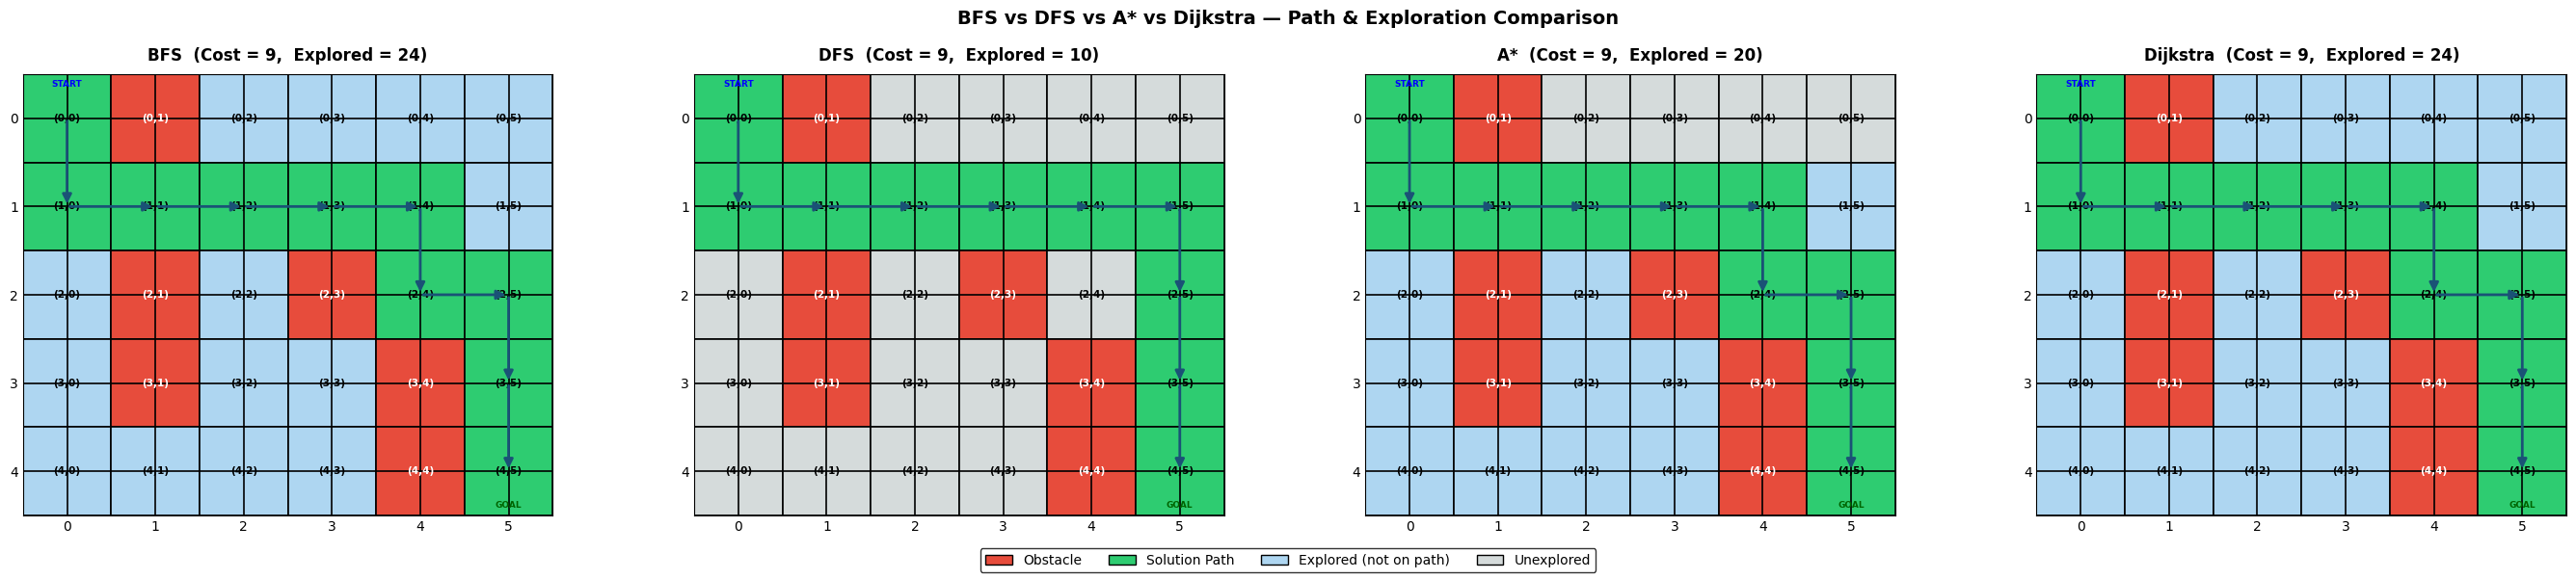

Figure saved as bfs_dfs_astar_dijkstra_comparison.png


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# 12. VISUALISATION — BFS vs DFS vs A* vs DIJKSTRA  (FOUR PANELS)
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Compute Dijkstra explored set ────────────────────────────────────
# IMPORTANT: use dij_log (nodes actually expanded / popped from heap)
# NOT dij_parent.keys() which includes all *discovered* nodes.
dij_path_set     = set(dij_path)
dij_explored_set = set(dij_log) - dij_path_set - OBSTACLES
dij_edges        = list(zip(dij_path[:-1], dij_path[1:]))

# ── Create figure with 4 panels ─────────────────────────────────────
fig_all4, (ax_bfs4, ax_dfs4, ax_astar4, ax_dij4) = plt.subplots(1, 4, figsize=(28, 6))

draw_maze(ax_bfs4,
          f"BFS  (Cost = {bfs_cost},  Explored = {bfs_nodes_explored})",
          bfs_path, bfs_edges, bfs_explored_set)

draw_maze(ax_dfs4,
          f"DFS  (Cost = {dfs_cost},  Explored = {dfs_nodes_explored})",
          dfs_path, dfs_edges, dfs_explored_set)

draw_maze(ax_astar4,
          f"A*  (Cost = {astar_cost},  Explored = {astar_nodes_explored})",
          astar_path, astar_edges, astar_explored_set)

draw_maze(ax_dij4,
          f"Dijkstra  (Cost = {dij_cost},  Explored = {dij_nodes_explored})",
          dij_path, dij_edges, dij_explored_set)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#e74c3c", edgecolor="black", label="Obstacle"),
    mpatches.Patch(facecolor="#2ecc71", edgecolor="black", label="Solution Path"),
    mpatches.Patch(facecolor="#aed6f1", edgecolor="black", label="Explored (not on path)"),
    mpatches.Patch(facecolor="#d5dbdb", edgecolor="black", label="Unexplored"),
]
fig_all4.legend(handles=legend_elements, loc="lower center", ncol=4,
                fontsize=10, frameon=True, edgecolor="black")

plt.suptitle("BFS vs DFS vs A* vs Dijkstra — Path & Exploration Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig("bfs_dfs_astar_dijkstra_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as bfs_dfs_astar_dijkstra_comparison.png")